# Notebook 19 - Patient-Level Evaluation

Loads saved nb17 probabilities.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

OUTPUTS_DIR = Path("d:/sop/outputs")
df = pd.read_csv(OUTPUTS_DIR / "cnn17_test_probs.csv")
df["patient"] = df["file"].apply(lambda s: re.match(r"[ap](\d+)_", s).group(1))

pat = df.groupby("patient").agg(
    label=("true_label", "first"),
    prob=("prob_nb17", "mean"),
).reset_index()

print(f"Test recordings : {len(df)}")
print(f"Unique patients : {len(pat)}")
print(f"Recordings/patient (mean): {len(df)/len(pat):.1f}")
print(f"Patient class balance -- absent: {(pat['label']==0).sum()}  present: {(pat['label']==1).sum()}")


Test recordings : 997
Unique patients : 166
Recordings/patient (mean): 6.0
Patient class balance -- absent: 139  present: 27


In [2]:
thrs = np.arange(0.20, 0.91, 0.01)
accs = [accuracy_score(pat["label"], (pat["prob"]>=t).astype(int)) for t in thrs]
bi   = int(np.argmax(accs))
best_thr = float(thrs[bi])
auc      = roc_auc_score(pat["label"], pat["prob"])
y_pred   = (pat["prob"] >= best_thr).astype(int)

print(f"Threshold : {best_thr:.2f}")
print(f"Accuracy  : {accs[bi]*100:.2f}%")
print(f"AUC       : {auc:.4f}")
print()
print(classification_report(pat["label"], y_pred, target_names=["absent","present"]))


Threshold : 0.61
Accuracy  : 95.78%
AUC       : 0.9643

              precision    recall  f1-score   support

      absent       0.99      0.96      0.97       139
     present       0.83      0.93      0.88        27

    accuracy                           0.96       166
   macro avg       0.91      0.94      0.93       166
weighted avg       0.96      0.96      0.96       166



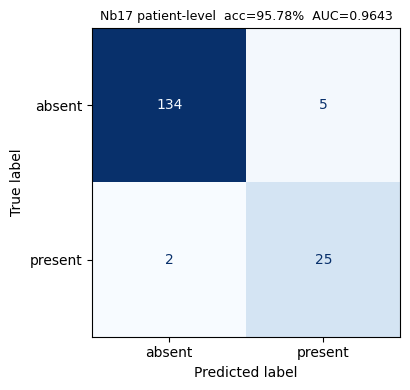

FN (missed murmurs) : 2
FP (false alarms)   : 5


In [3]:
cm = confusion_matrix(pat["label"], y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["absent","present"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Nb17 patient-level  acc={accs[bi]*100:.2f}%  AUC={auc:.4f}", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cnn17_patient_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"FN (missed murmurs) : {fn}")
print(f"FP (false alarms)   : {fp}")
